In [ ]:
pip install transformers torch torchvision sentencepiece


In [7]:
from google.colab import files
uploaded = files.upload()  # opens file picker, select your image
image = Image.open(list(uploaded.keys())[0])

Saving office.png to office (1).png


In [8]:
from transformers import AutoModel
from torchvision import transforms
from PIL import Image
import requests

model = AutoModel.from_pretrained("google/tipsv2-b14-dpt", trust_remote_code=True)
model.eval().cuda()

url = "https://huggingface.co/spaces/google/tipsv2/resolve/main/examples/depth/ade20k_00014.png"
transform = transforms.Compose([transforms.Resize((448, 448)), transforms.ToTensor()])
pixel_values = transform(image).unsqueeze(0).cuda()

# All tasks at once
outputs = model(pixel_values)
print(outputs.depth.shape)         # (1, 1, 448, 448) — depth map
print(outputs.normals.shape)       # (1, 3, 448, 448) — surface normals
print(outputs.segmentation.shape)  # (1, 150, 448, 448) — segmentation logits

# Or individual tasks (only runs the requested head)
depth = model.predict_depth(pixel_values)
normals = model.predict_normals(pixel_values)
seg = model.predict_segmentation(pixel_values)
print(seg.argmax(dim=1).shape)     # (1, 448, 448) — per-pixel class prediction


Loading weights:   0%|          | 0/156 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

configuration_tips.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/google/tipsv2-b14:
- configuration_tips.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_tips.py: 0.00B [00:00, ?B/s]

...

image_encoder.py: 0.00B [00:00, ?B/s]

/root/.cache/huggingface/hub/models--google--tipsv2-b14/snapshots/245de45054528d86029a06375bd7ba12a93f5b20/image_encoder.py:175: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")


text_encoder.py: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/323 [00:00<?, ?it/s]

torch.Size([1, 1, 448, 448])
torch.Size([1, 3, 448, 448])
torch.Size([1, 150, 448, 448])
torch.Size([1, 448, 448])


In [9]:
depth

tensor([[[[2.3381, 2.3378, 2.3372,  ..., 3.9435, 3.8676, 3.8201],
          [2.3319, 2.3314, 2.3306,  ..., 3.9772, 3.8985, 3.8493],
          [2.3220, 2.3212, 2.3199,  ..., 4.0311, 3.9480, 3.8961],
          ...,
          [1.7445, 1.7437, 1.7424,  ..., 2.0700, 2.0620, 2.0569],
          [1.7538, 1.7532, 1.7522,  ..., 2.0790, 2.0702, 2.0647],
          [1.7596, 1.7591, 1.7584,  ..., 2.0846, 2.0753, 2.0695]]]],
       device='cuda:0')

In [10]:
print(outputs.depth.min().item(), outputs.depth.max().item())

1.5274748802185059 6.206563949584961


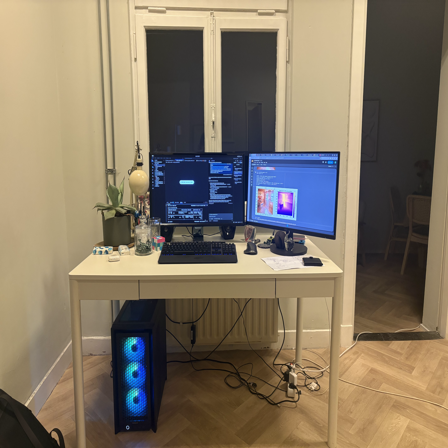

In [11]:
image.resize((448, 448))

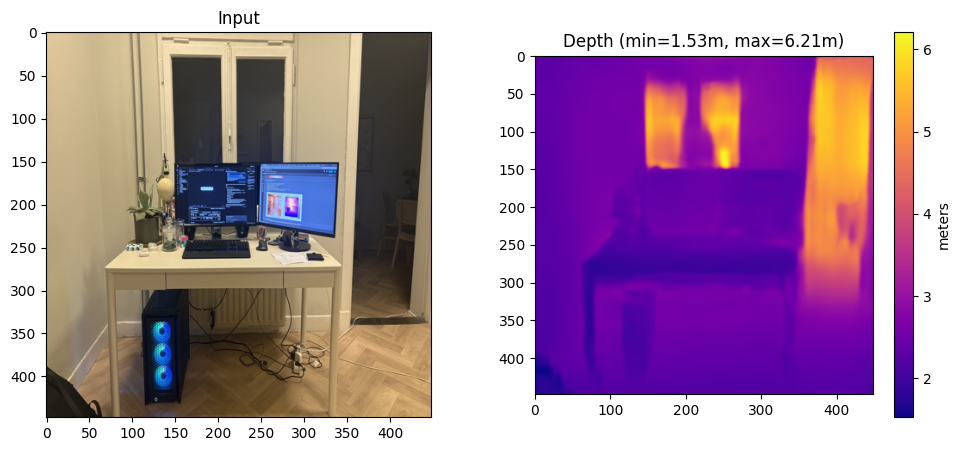

In [13]:
import matplotlib.pyplot as plt
import numpy as np

depth = outputs.depth.squeeze().detach().cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image.resize((448, 448)))
axes[0].set_title("Input")
axes[1].imshow(depth, cmap='plasma')
axes[1].set_title(f"Depth (min={depth.min():.2f}m, max={depth.max():.2f}m)")
plt.colorbar(axes[1].images[0], ax=axes[1], label='meters')
plt.show()

In [ ]:
import requests
url = "https://raw.githubusercontent.com/CSAILVision/semantic-segmentation-pytorch/master/data/object150_info.csv"
r = requests.get(url)
print(r.text[:1000])

Idx,Ratio,Train,Val,Stuff,Name
1,0.1576,11664,1172,1,wall
2,0.1072,6046,612,1,building;edifice
3,0.0878,8265,796,1,sky
4,0.0621,9336,917,1,floor;flooring
5,0.0480,6678,641,0,tree
6,0.0450,6604,643,1,ceiling
7,0.0398,4023,408,1,road;route
8,0.0231,1906,199,0,bed
9,0.0198,4688,460,0,windowpane;window
10,0.0183,2423,225,1,grass
11,0.0181,2874,294,0,cabinet
12,0.0166,3068,310,1,sidewalk;pavement
13,0.0160,5075,526,0,person;individual;someone;somebody;mortal;soul
14,0.0151,1804,190,1,earth;ground
15,0.0118,6666,796,0,door;double;door
16,0.0110,4269,411,0,table
17,0.0109,1691,160,1,mountain;mount
18,0.0104,3999,441,0,plant;flora;plant;life
19,0.0104,2149,217,0,curtain;drape;drapery;mantle;pall
20,0.0103,3261,318,0,chair
21,0.0098,3164,306,0,car;auto;automobile;machine;motorcar
22,0.0074,709,75,1,water
23,0.0067,3296,315,0,painting;picture
24,0.0065,1191,106,0,sofa;couch;lounge
25,0.0061,1516,162,0,shelf
26,0.0060,667,69,1,house
27,0.0053,651,57,1,sea
28,0.0052,1847,224,0,mirror
29,0.0046,115

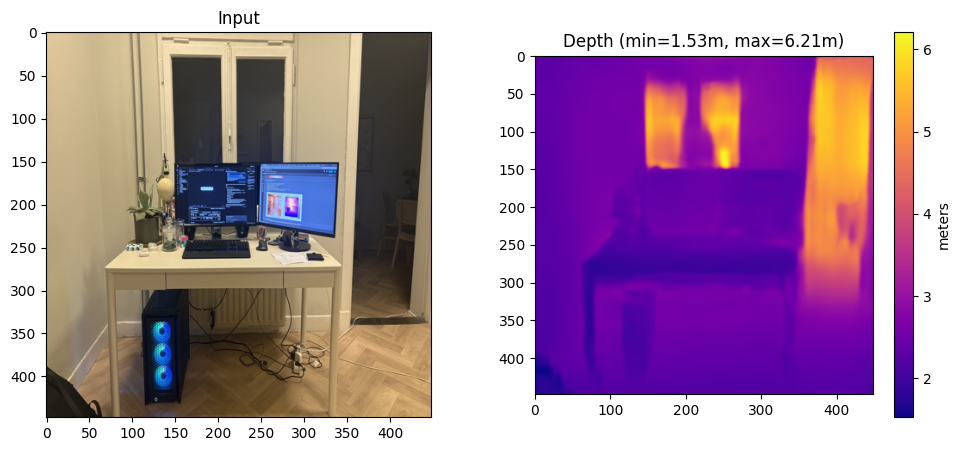

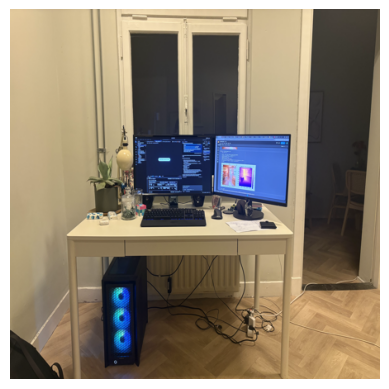

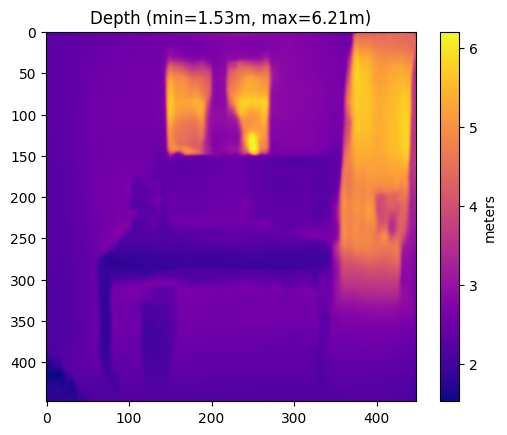

In [15]:
import matplotlib.pyplot as plt
import numpy as np

depth = outputs.depth.squeeze().detach().cpu().numpy()

# Side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image.resize((448, 448)))
axes[0].set_title("Input")
axes[1].imshow(depth, cmap='plasma')
axes[1].set_title(f"Depth (min={depth.min():.2f}m, max={depth.max():.2f}m)")
plt.colorbar(axes[1].images[0], ax=axes[1], label='meters')
plt.savefig("/content/depth_visualization.png", bbox_inches='tight', dpi=150)
plt.show()

# Original only
fig2, ax2 = plt.subplots()
ax2.imshow(image.resize((448, 448)))
ax2.axis('off')
fig2.savefig("/content/original.png", bbox_inches='tight', dpi=150)
plt.show()

# Depth only with colorbar and axes
fig3, ax3 = plt.subplots()
im = ax3.imshow(depth, cmap='plasma')
ax3.set_title(f"Depth (min={depth.min():.2f}m, max={depth.max():.2f}m)")
plt.colorbar(im, ax=ax3, label='meters')
fig3.savefig("/content/depth.png", bbox_inches='tight', dpi=150)
plt.show()